# Supermarket Sales Analysis

# Project Objective

The goal of this project is to analyze supermarket sales data and identify:

- Revenue trends
- Customer behavior
- Product performance
- Branch performance

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("supermarket_sales new.csv")
df.columns = df.columns.str.strip().str.lower().str.replace(" ","_")

In [3]:
df.head()

,gender,invoice_id,branch,city,customer_type,product_line,unit_price,quantity,tax_5%
0,Female,750-67-8428,A,Yangon,Member,Health and beauty,74.69,7,261.415
1,Female,226-31-3081,C,Naypyitaw,Normal,Electronic accessories,15.28,5,3.820
2,Female,355-53-5943,A,Yangon,Member,Electronic accessories,68.84,6,20.652
3,Female,315-22-5665,C,Naypyitaw,Normal,Home and lifestyle,73.56,10,36.780
4,Female,665-32-9167,A,Yangon,Member,Health and beauty,36.26,2,3.626


In [4]:
df.columns

Index(['gender', 'invoice_id', 'branch', 'city', 'customer_type',
       'product_line', 'unit_price', 'quantity', 'tax_5%'],
      dtype='object')

## Revenue Analysis

In [5]:
# the total revenue, total tax collected, and total quantity sold

df["revenue"] = df["unit_price"] * df["quantity"] + df["tax_5%"]
print(df[["revenue", "quantity", "tax_5%"]].sum().round(2))

revenue     351498.77
quantity      5510.00
tax_5%       43911.39
dtype: float64


In [6]:
# branch generates the highest total revenue and the highest average sale per transaction

df.groupby('branch')["revenue"].agg(["sum", "mean", "count"]).round(2)

,sum,mean,count
branch,,,
A,116366.95,342.26,340
B,113780.72,342.71,332
C,121351.11,369.97,328


In [7]:
# product line has the highest total revenue? Which has the highest average unit price

df.groupby("product_line")["revenue"].sum().sort_values(ascending = False).round(2).head(1)
df.groupby("product_line")["unit_price"].mean().sort_values(ascending = False).head(1)

product_line
Fashion accessories    57.153652
Name: unit_price, dtype: float64

## Customer Analysis

In [8]:
#  Members spend more per transaction than Normal customers

df.groupby("customer_type")["revenue"].agg(["sum","mean","count"]).sort_values("mean", ascending = False).round(2)

,sum,mean,count
customer_type,,,
Member,179208.41,357.70,501
Normal,172290.36,345.27,499


In [9]:
# gender spends more on average, and which product lines are gender-dominant

df.groupby("gender")["revenue"].mean().round(2)
df.groupby(["product_line", "gender"])["revenue"].sum().round(2).unstack()

gender,Female,Male
product_line,,
Electronic accessories,28753.82,29199.85
Fashion accessories,34430.98,27624.90
Food and beverages,34919.49,23898.94
Health and beauty,20955.97,32787.33
Home and lifestyle,32458.09,26490.18
Sports and travel,31059.77,28919.45


## Customer Analysis

In [10]:
# the average quantity purchased per product line 

df.groupby("product_line")["quantity"].mean().round(2).reset_index()

,product_line,quantity
0,Electronic accessories,5.71
1,Fashion accessories,5.07
2,Food and beverages,5.47
3,Health and beauty,5.62
4,Home and lifestyle,5.69
5,Sports and travel,5.54


In [11]:
#  city has the highest tax collected

df.groupby("city")["tax_5%"].sum().round(2).sort_values(ascending = False)

city
Naypyitaw    16047.58
Yangon       15223.74
Mandalay     12640.08
Name: tax_5%, dtype: float64

## Visualizations using Matolotlib

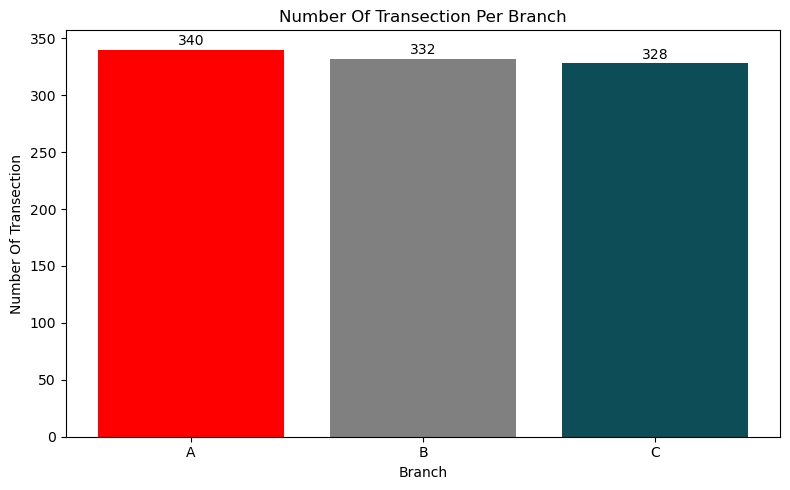

In [12]:
#  transactions were made in each Branch (A, B, C)

branch_count = df.groupby("branch")["invoice_id"].count()

fig , ax = plt.subplots(figsize = (8 , 5))
color = ["red", "grey", "#0d4d57"]
bars = ax.bar(branch_count.index , branch_count.values, color = color )

for bar, val in zip(bars , branch_count.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 4,
            str(val) , ha = "center")

ax.set_title("Number Of Transection Per Branch")
ax.set_xlabel("Branch")
ax.set_ylabel("Number Of Transection")
plt.tight_layout()
plt.show()

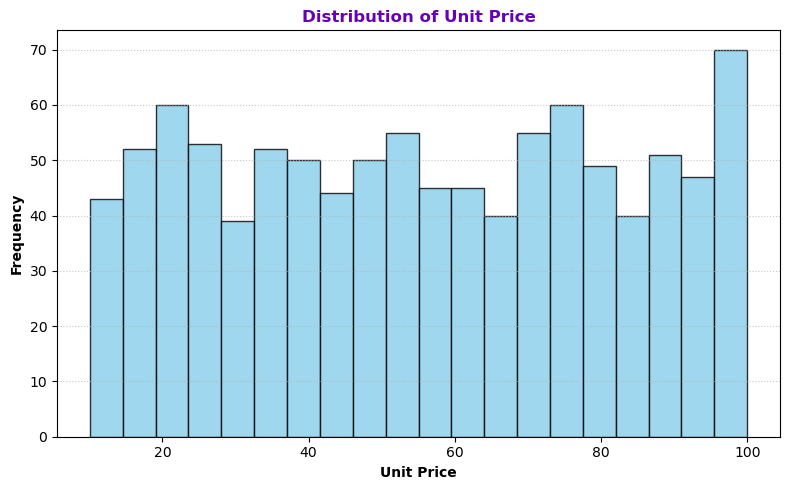

In [13]:
# the distribution of Unit Price look like

plt.figure(figsize = (8,5))

plt.hist(
    df["unit_price"],
    bins = 20,
    color = "skyblue",
    edgecolor = "black",
    alpha = 0.8)

plt.title("Distribution of Unit Price" , color = "#6602b3" , fontweight = "bold")
plt.xlabel("Unit Price" , fontweight = "bold")
plt.ylabel("Frequency", fontweight = "bold")

plt.grid(axis = "y" , alpha = 0.7 , linestyle = "dotted")

plt.tight_layout()
plt.show()

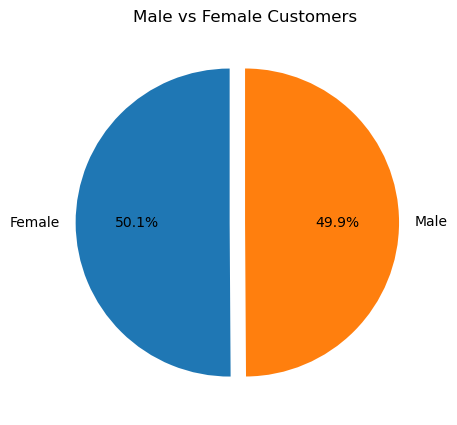

In [14]:
# Male vs Female customers are there

gender_count = df["gender"].value_counts()

plt.figure(figsize = (8,5))

plt.pie(
    gender_count.values,
    labels = gender_count.index,
    autopct = "%1.1f%%",
    startangle = 90,
    explode = [0.1 , 0],
    
)

plt.title("Male vs Female Customers")

plt.show()

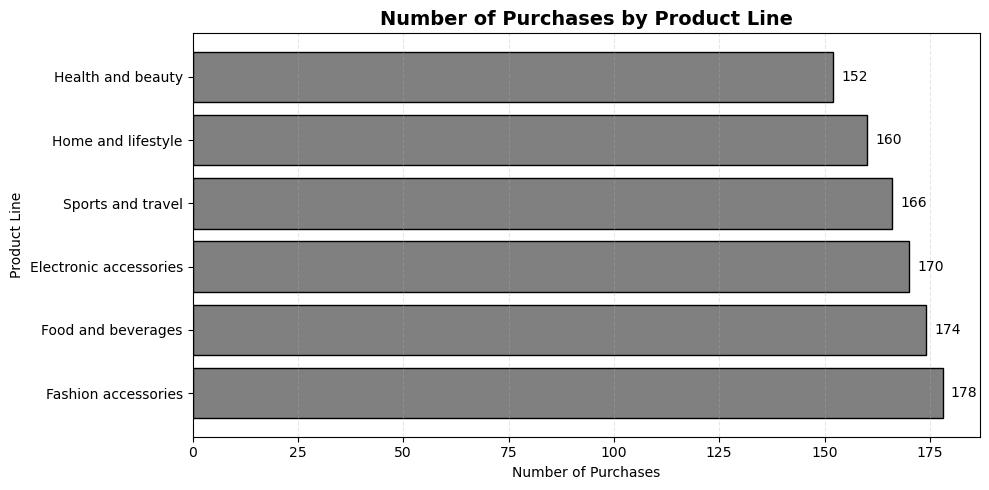

Most Purchased Product Line : Fashion accessories
Total Purchased : 178


In [18]:
# Product Line had the most purchases

product_count = df["product_line"].value_counts().sort_values(ascending = False)

plt.figure(figsize = (10,5))
bars = plt.barh(
    product_count.index,
    product_count.values,
    color = "Grey",
    edgecolor = "black"
)

for bars , val in zip(bars , product_count.values):
    plt.text(
        bars.get_width() + 2,
        bars.get_y() + bars.get_height() / 2,
        str(val),
        va = "center",
        fontsize = 10
    )


plt.title("Number of Purchases by Product Line", fontsize=14, fontweight="bold")
plt.xlabel("Number of Purchases")
plt.ylabel("Product Line")
plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()


plt.show()
print("Most Purchased Product Line :" , product_count.idxmax())
print("Total Purchased :", product_count.max())

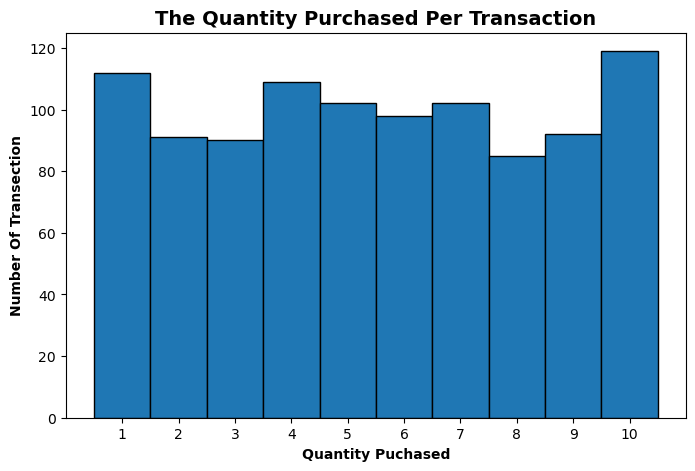

In [19]:
#  the Quantity purchased per transaction look like

plt.figure(figsize = (8,5))

plt.hist(
    df["quantity"],
    bins = range(1,12),
    edgecolor = "black",
    align = "left"
)
plt.title("The Quantity Purchased Per Transaction", fontsize=14, fontweight="bold")
plt.ylabel("Number Of Transection" , fontweight="bold")
plt.xlabel("Quantity Puchased" , fontweight="bold")
plt.xticks(range(1,11))
plt.show()

# Key Insights

1. Branch A generated the highest revenue. 

2. Members spend more on average than Normal customers.

3. Product Line "Fashion accessories" produced the highest sales.

4. City Naypyitaw generated the highest tax collection.

5. Male/Female customers showed different purchasing patterns.